In [7]:
# 작업디렉토리 변경
%cd "/content/drive/MyDrive/AI/26.06.10 자연어처리"

from google.colab import drive
drive.mount('/content/drive')

[Errno 2] No such file or directory: '/content/drive/MyDrive/AI/26.06.10 자연어처리'
/content
Mounted at /content/drive


### 텍스트마이닝
- 비정형 텍스트데이터에서 의미를 추출하거나 정형화된 데이터로 변경하는 작업
- 사람의 언어를 이해하는 관련기술을 자연어처리라고하며 기술적으로 겹치는 영역이 많다

### 텍스트 마이닝 분석 프로세스

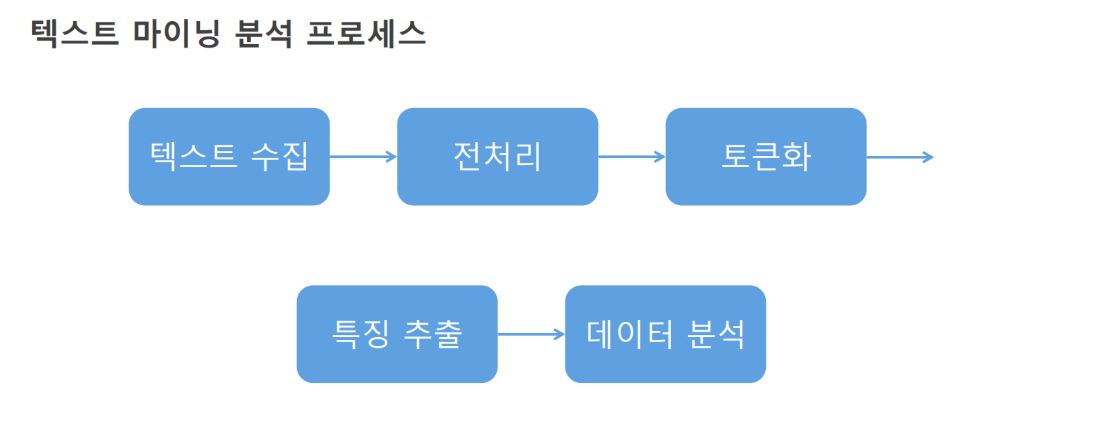

### 1.빈도분석
- 네이버쇼핑 리뷰데이터
- https://github.com/bab2min/corpus/tree/master/sentiment
- 네이버 쇼핑에 있는 댓글을 수집한 데이터로 구분자는 \t이다. 평점과 리뷰 두 개의 컬럼을 가지고 있다

In [8]:
# pandas 이용해서 데이터를 읽고 전체 갯수를 확인해보자
# 주의사항 : 구분자를 \t로 설정해야 올바르게 읽어진다
import pandas as pd

In [17]:
naver_df = pd.read_csv("/content/drive/My Drive/AI/data/naver_shopping.txt",
                       sep="\t", # 구분자 변경
                       header=None) # 컬럼정보 없음을 명시
# 컬럼명 변경
naver_df.columns = ["평점","리뷰"]
naver_df.head()

,평점,리뷰
0,5,배공빠르고 굿
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고
2,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...
3,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...
4,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ


In [ ]:
# 데이터 갯수 확인
naver_df.shape

#### 말뭉치와 문서
- 말뭉치(corpus) : 텍스트마이닝,자연어처리에서 사용되는 데이터셋 덩어리
- 문서(document) : 말뭉치는 구성하는 개별 text 요소

#### 토큰화
- 토큰화(Tokenize) : 일정단위로 문장을 조깨는 작업
  1. 글자(char)
  2. 단어(띄어쓰기)
  3. 형태소
  4. N-gram

In [ ]:
# 모든 문서를 토큰화하자
tokens = [] # 20만개의 리뷰의 모든 토큰을 담을 리스트
for doc in naver_df['리뷰'] : # 리뷰열을 꺼내서 반복
  for token in doc.split(" ") : # 띄어쓰기 중심으로 각 리뷰들을 토큰화
    tokens.append(token) # 잘라낸 개별토큰을 리스트에 추가

In [ ]:
tokens

#### 특징추출(수치화)
- 의미있는 숫자를 뽑아내는 작업
- 우리는 빈도를 기반으로 숫자를 뽑아보자

In [ ]:
from collections import Counter

In [5]:
# 도구생성
counter = Counter(tokens) # 토큰화된 데이터를 넣어서 생성

NameError: name 'Counter' is not defined

In [ ]:
# 빈도확인
counter.most_common(20) # 빈도가 높은 상위 20개 데이터 확인

#### 실습
- 배송과 관련된 리뷰들에서 자주 등장하는 상위 20개 단어를 확인해보자
- 진행순서
  1. 배송단어가 들어간 리뷰 필터링
  2. 토큰화 실시
  3. 카운터로 빈도 측정 및 확인
- 필터링관련 함수 : https://pandas.pydata.org/docs/reference/api/pandas.Series.str.contains.html#pandas.Series.str.contains

In [ ]:
# 리뷰에 배송이 포함된 글자 필터링
배송_df = naver_df[naver_df['리뷰'].str.contains("배송")]
배송_df.shape

In [ ]:
# for doc in 배송_df['리뷰'] :
#  for token in doc.split(" ") :
#    tokens.append(token)

In [ ]:
# 리스트 컴프리헨션 문법 활용
tokens = [ token  for doc in 배송_df['리뷰'] for token in doc.split(" ")]

In [ ]:
tokens

In [ ]:
# 도구생성
counter = Counter(tokens) # 토큰화된 데이터를 넣어서 생성
# 빈도확인
counter.most_common(20) # 빈도가 높은 상위 20개 데이터 확인

### 2.정규표현식(Regular Expression)
- 특정한 규칙을 가진 문자열의 집합을 표현하는 언어
- 핸드폰번호, 이메일처럼 패턴이 있는 문자열을 검색,치환하는 도구
- 대부분의 프로그래밍 언어에서 지원
- https://wikidocs.net/21703

In [ ]:
# 정규표현식을 지원하는 패키지 임포트
import re

In [ ]:
# 핸드폰 번호 검출
# 패턴 만들기
p = re.compile("010-?[0-9]{4}-?\\d{4}")

In [ ]:
p.search("안녕하세요 제 핸드폰 번호는 010-1234-5678입니다.")

In [ ]:
p.search("안녕하세요 제 핸드폰 번호는 01012345678입니다.")

In [ ]:
p.search("안녕하세요 제 핸드폰 번호는 0101234567입니다.")

#### 배송이 포함된 데이터 클렌징하기
- 숫자
- 알파벳(대소문자)
- 문장부호(!?~ 등)
- 반복적인 글자(ㅋ,ㅎ,ㅠ,ㅇ 등)
- 실습순서
  1. 패턴만들기
  2. 문장 토큰화
  3. search 이용해서 패턴에 검출된 토큰은 제외하고 전체 리스트에 추가

In [ ]:
배송_df.head()

In [ ]:
# 패턴생성
p = re.compile("[0-9a-zA-Z?!@~.ㅋㅎㅠㅜㅇㅡ^]+")

In [ ]:
clean_review = [] # 전처리가 끝난 데이터를 담을 리스트
for doc in 배송_df['리뷰'] : # 배송과 관련된 리뷰를 반복
  temp = [] # doc단위로 묶기 위한 임시 리스트
  for token in doc.split(" ") : # 하나의 리뷰를 띄어쓰기 중심으로 토큰화
    if not p.search(token) : # 패턴과 일치여부를 검사
      temp.append(token) # doc단위 리스트에 클린토큰 추가
  clean_review.append(temp) # 전체리스트에 doc단위로 추가

In [ ]:
clean_review

### 3.형태소 분석
- 형태소 의미를 가진 가장 작은 단위
- Konlpy : https://konlpy.org/ko/latest/index.html
- Kiwi : https://github.com/bab2min/kiwipiepy

#### mecab 설치하기

In [ ]:
# !git clone https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git

In [ ]:
# !bash ./Mecab-ko-for-Google-Colab/install_mecab-ko_on_colab_light_220429.sh

In [ ]:
from konlpy.tag import Mecab,Okt,Kkma

In [ ]:
okt = Okt() # 트위터 기반으로 시작된 형태소 분석기, 비교적 신조어 분리에 강함
mecab = Mecab() # 리눅스기반의 환경에서 동작, 속도가 빠르다
kkma = Kkma() # Java기반의 분석기, 속도는 느리지만 품사분리가 정교하다

In [ ]:
# 형태소분리
mecab.morphs("아버지 가방에 들어가신다")

In [ ]:
# 품사확인하기
print(okt.tagset)
print(kkma.tagset)

In [ ]:
# pos tagging
" ".join(clean_review[0])

In [ ]:
result =  kkma.pos(" ".join(clean_review[0]))

In [ ]:
# 반복문으로 명사 추출하기
for t in result :
  if t[1] == 'NNG' :
    print(t[0], t[1])

#### 실습 : 배송관련 리뷰에서 명사만 추출하여 빈도분석하기

In [ ]:
noun_tokens = [] # 명사만 들어갈 전체리스트
for doc in 배송_df['리뷰'] :
  # 형태소분석기를 이용해 품사 확인하기
  morphs = okt.pos(doc) # 형태소 분리
  for t in morphs : # 형태소별로 반복처리
    if t[1] == "Noun" : # 명사만 필터링
      noun_tokens.append(t[0]) # 형태소 토큰 추가

In [ ]:
# 도구생성
counter = Counter(noun_tokens) # 토큰화된 데이터를 넣어서 생성
# 빈도확인
counter.most_common(20) # 빈도가 높은 상위 20개 데이터 확인

#### kiwi 사용하기
- https://github.com/bab2min/kiwi
- https://github.com/bab2min/kiwipiepy

In [ ]:
!pip install kiwipiepy

In [ ]:
from kiwipiepy import Kiwi

In [ ]:
# 도구생성
kiwi = Kiwi()

In [ ]:
# 형태소단위로 분리
rs = kiwi.tokenize("아버지가 방에 들어가신다.")

In [ ]:
rs

In [ ]:
# 토큰에 접근하기
rs[0]

In [ ]:
# 데이터 꺼내기
print(rs[0].form)
print(rs[0].tag)

In [ ]:
# 띄어쓰기 교정
kiwi.space("아버지가방에들어가신다.")

### 4.불용어(Stop word) 처리
- 분석에 사용되지 않는 단어를 제거하는 기법

In [ ]:
# 불용어 리스트
stop_words = ["배송", "좀", "개", "더", "것", "때"]

In [ ]:
noun_tokens_remove_stop = [] # 불용어처리된 토큰이 담길 리스트

for token in noun_tokens : # 전체토큰 반복
  if token not in stop_words : # 불용어가 아니라면
    noun_tokens_remove_stop.append(token) # 추가

In [ ]:
# 도구생성
counter = Counter(noun_tokens_remove_stop) # 토큰화된 데이터를 넣어서 생성
# 빈도확인
counter.most_common(20) # 빈도가 높은 상위 20개 데이터 확인

### 5.이모지 처리

In [ ]:
# 패키지 설치
!pip install emoji

In [ ]:
import emoji

In [ ]:
# 이모지 제거
emoji.replace_emoji("이 쇼핑몰 너무 좋아요. 빠른 배송 감사합니다. 😍💕")

In [ ]:
# 이모지 글자를 살리는 경우
emoji.demojize("이 쇼핑몰 너무 좋아요. 빠른 배송 감사합니다. 😍💕")

### 6.N-gram
- 연속적인 단어의 의미 보존을 위해 처리하는 방법
- 1-gram(유니그램) : 한 단어(글자)를 토큰으로 등록
- 2-gram(바이그램) : 두 단어(글자)를 토큰으로 등록
- 3-gram(트라이그램) : 세 단어(글자)를 토큰으로 등록
- 너무 과도하고 n-gram을 쓸 경우 토큰화의 의미가 감소

In [ ]:
from nltk.util import ngrams

In [ ]:
# 토큰화된 예시데이터 준비
sample_tokens = ['오늘','저녁에','무엇을','먹을까',"?"]

In [ ]:
# 바이그램
bi_result = list(ngrams(sample_tokens,2))

In [ ]:
bi_result

In [ ]:
# 트라이그램
tri_result = list(ngrams(sample_tokens,3))

In [ ]:
tri_result

### N-gram을 적용해서 빈도분석 해보기
- kiwi 활용
- 유니,바이,트라이 적용 후 빈도 측정

In [ ]:
clean_reviews = [] # NNG,VV,VA로 클렌징된 리스트

for doc in 배송_df['리뷰'] : # 배송리뷰 반복처리
  morphs = kiwi.tokenize(doc) # 형태소분석
  morphs_tokens = [] # 일반명사, 동사, 형용사만 필터링하는 리스트
  for t in morphs : # 토큰 반복처리
    if t.tag in ['NNG',"VV","VA"] : # 조건처리
      morphs_tokens.append(t.form) # 토큰추가

  clean_reviews.append(morphs_tokens) # 전체리스트에 추가

In [ ]:
clean_reviews

In [ ]:
n_gram_clean_reviews = [] # n-gram이 적용된 리뷰를 담을 리스트

for doc in clean_reviews : # 클렌징된 전체데이터를 반복
  temp_tokens = [] # 하나의 리뷰에 대한 중간결과 리스트 <- (유니그램 토큰, 바이그램 토큰)
  bi_tokens = list(ngrams(doc,2)) # 바이그램 생성
  tri_tokens = list(ngrams(doc,3)) # 트라이그램 생성
  # 유니그램 데이터 추가
  temp_tokens = temp_tokens + doc
  # 바이그램 데이터 추가
  for t in bi_tokens :
    temp_tokens.append(" ".join(t)) # 두 단어를 하나의 문자열로 결합하여 추가
  # 트라이그램 데이터 추가
  for t in tri_tokens :
    temp_tokens.append(" ".join(t)) # 두 단어를 하나의 문자열로 결합하여 추가
  n_gram_clean_reviews.append(temp_tokens) # 전체리스트에 추가

In [ ]:
# 빈도분석
# 하나의 리스트에 모든 토큰 담기
배송_n_gram_tokens = [ t  for doc in n_gram_clean_reviews for t in doc]

# 빈도측정
counter = Counter(배송_n_gram_tokens)
counter.most_common(50)